In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [4]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display (dt4training)
display (dt4testing)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


##Model 1 - Multiple Regression (Production + coolDD)
##Model 1 MAPE = 21.7%

In [6]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production', 'coolDD']]

x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()

model1.params

,0
const,1544742.70
production,31.98
coolDD,-23477.27


revenue = 1544742.7 + 31.98 * production - 23477.27 * coolDD



In [15]:
x_test = dt4testing.loc[:, ['production', 'coolDD']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)
model1_assessment['model1_abs_pct_error'] = abs((model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue'])/model1_assessment['revenue'])

display(model1_assessment)


,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,20938961.80,0.09
37,dt4testing,2014-02-28,26792280,714128,0,938,24384378.09,0.09
38,dt4testing,2014-03-31,19935840,805600,0,866,27309886.02,0.37
39,dt4testing,2014-04-30,13468000,375856,0,412,13565576.50,0.01
40,dt4testing,2014-05-31,7344128,279296,49,88,9326955.28,0.27
41,dt4testing,2014-06-30,11196216,517600,230,0,12699139.92,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,16593408.05,0.19
43,dt4testing,2014-08-31,12352176,663432,322,0,15203310.81,0.23
44,dt4testing,2014-09-30,12628944,701656,178,14,19806538.25,0.57
45,dt4testing,2014-10-31,9361000,411728,24,166,14149400.18,0.51


In [13]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.21738596854659376)

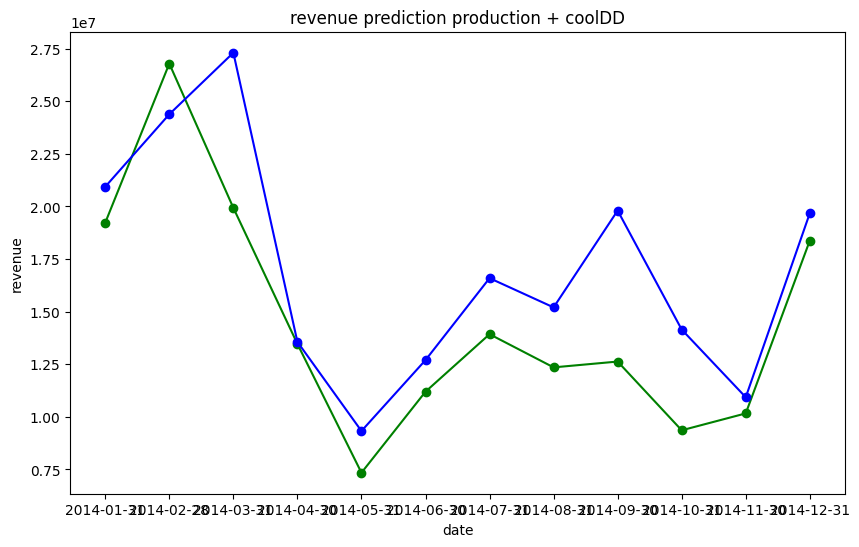

In [14]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction production + coolDD')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o', color='green')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker ='o', color='blue')

find the best model - univariate regression models on production cooldd, heatdd
make multiple regession models

submit colab file showing your models being made and then a final visualization and text cell comparing your different models.      

the best model is production + heatdd because it has a mape score of xyz while the others have a mape score of abc

##Model 2 - Production Only
##Model 2 MAPE = 25.4%

In [18]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production']]

x = sm.add_constant(x)

model2 = sm.OLS(y, x).fit()

display(model2.params)

,0
const,4897663.26
production,18.99


revenue = 4897663.26 + 18.99*production

In [21]:
x_test = dt4testing.loc[:,['production']]
x_test = sm.add_constant(x_test)

model2_assessment = dt4testing.copy()

model2_assessment['model2_predicted_revenue'] = model2.predict(x_test)

model2_assessment['model2_abs_pct_error'] = abs((model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue'])/model2_assessment['revenue'])


display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [22]:
model2_assessment['model2_abs_pct_error'].mean()

np.float64(0.2542315606071484)

##Model 3 - CoolDD
##Model 3 MAPE = 29.6%

In [23]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['coolDD']]

x = sm.add_constant(x)

model3 = sm.OLS(y, x).fit()

display(model3.params)

,0
const,14341632.04
coolDD,-4113.94


revenue = 14341632.04 - 4113.94*coolDD

In [25]:
x_test = dt4testing.loc[:,['coolDD']]
x_test = sm.add_constant(x_test)

model3_assessment = dt4testing.copy()

model3_assessment['model3_predicted_revenue'] = model3.predict(x_test)

model3_assessment['model3_abs_pct_error'] = abs(
    (model3_assessment['revenue'] - model3_assessment['model3_predicted_revenue'])/model3_assessment['revenue'])

display(model3_assessment)

,type,date,revenue,production,coolDD,heatDD,model3_predicted_revenue,model3_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,0.52


In [26]:
model3_assessment['model3_abs_pct_error'].mean()

np.float64(0.2960295810593141)

##Model 4 - heatDD
##Model 4 MAPE = 21.6%

In [27]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['heatDD']]

x = sm.add_constant(x)

model4 = sm.OLS(y, x).fit()

display(model4.params)

,0
const,10333861.28
heatDD,9991.26


revenue = 10333861.28 + 9991.26*heatDD


In [28]:
x_test = dt4testing.loc[:,['heatDD']]
x_test = sm.add_constant(x_test)

model4_assessment = dt4testing.copy()

model4_assessment['model4_predicted_revenue'] = model4.predict(x_test)

model4_assessment['model4_abs_pct_error'] = abs(
    (
        model4_assessment['revenue'] - model4_assessment['model4_predicted_revenue']
        )/model4_assessment['revenue']
    )

display(model4_assessment)

,type,date,revenue,production,coolDD,heatDD,model4_predicted_revenue,model4_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,21554043.42,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,19705660.79,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,18986290.25,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14450259.35,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,11213091.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,10333861.28,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,10333861.28,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,10333861.28,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,10473738.88,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,11992410.02,0.28


In [29]:
model4_assessment['model4_abs_pct_error'].mean()

np.float64(0.21648503280089135)

##Model 5 - Multiple Regression (Production + heatDD)
##Model 5 MAPE = 13.8578%

In [30]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','heatDD']]

x = sm.add_constant(x)

model5 = sm.OLS(y, x).fit()

display(model5.params)

,0
const,727257.88
production,20.00
heatDD,10484.05


revenue = 727257.88 + 20.00*production + 10484.05 * heatDD

In [31]:
x_test = dt4testing.loc[:,['production','heatDD']]
x_test = sm.add_constant(x_test)

model5_assessment = dt4testing.copy()

model5_assessment['model5_predicted_revenue'] = model5.predict(x_test)

model5_assessment['model5_abs_pct_error'] = abs((model5_assessment['revenue'] - model5_assessment['model5_predicted_revenue'])/model5_assessment['revenue'])

display(model5_assessment)

,type,date,revenue,production,coolDD,heatDD,model5_predicted_revenue,model5_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,24628392.67,0.28
37,dt4testing,2014-02-28,26792280,714128,0,938,24843321.50,0.07
38,dt4testing,2014-03-31,19935840,805600,0,866,25917840.64,0.30
39,dt4testing,2014-04-30,13468000,375856,0,412,12563524.46,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,7235563.93,0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,11078867.46,0.01
42,dt4testing,2014-07-31,13929472,749472,380,0,15716132.56,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,13995397.46,0.13
44,dt4testing,2014-09-30,12628944,701656,178,14,14906625.37,0.18
45,dt4testing,2014-10-31,9361000,411728,24,166,10701860.21,0.14


In [32]:
model5_assessment['model5_abs_pct_error'].mean()

np.float64(0.13857863869363204)

##Model 6 - Multiple Regression (Production + heatDD)
##Model 6 MAPE = 13.8698%

In [33]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['coolDD','heatDD']]

x = sm.add_constant(x)

model6 = sm.OLS(y, x).fit()

display(model6.params)

,0
const,4808087.92
coolDD,22847.06
heatDD,18008.95


revenue = 4808087.92 + 22847.06 * coolDD + 18008.95 * heatDD

In [35]:
x_test = dt4testing.loc[:,['coolDD','heatDD']]
x_test = sm.add_constant(x_test)

model6_assessment = dt4testing.copy()

model6_assessment['model6_predicted_revenue'] = model6.predict(x_test)

model6_assessment['model6_abs_pct_error'] = abs(
    (model6_assessment['revenue'] - model6_assessment['model6_predicted_revenue'])/model6_assessment['revenue'])

display(model6_assessment)

,type,date,revenue,production,coolDD,heatDD,model6_predicted_revenue,model6_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,25032135.65,0.30
37,dt4testing,2014-02-28,26792280,714128,0,938,21700480.42,0.19
38,dt4testing,2014-03-31,19935840,805600,0,866,20403836.22,0.02
39,dt4testing,2014-04-30,13468000,375856,0,412,12227774.18,0.09
40,dt4testing,2014-05-31,7344128,279296,49,88,7512381.01,0.02
41,dt4testing,2014-06-30,11196216,517600,230,0,10062910.76,0.10
42,dt4testing,2014-07-31,13929472,749472,380,0,13489969.14,0.03
43,dt4testing,2014-08-31,12352176,663432,322,0,12164839.90,0.02
44,dt4testing,2014-09-30,12628944,701656,178,14,9126989.12,0.28
45,dt4testing,2014-10-31,9361000,411728,24,166,8345902.50,0.11


In [36]:
model6_assessment['model6_abs_pct_error'].mean()

np.float64(0.13869856580272627)

##Model 7 - Multiple Regression (Production + heatDD + coolDD)
##Model 7 MAPE = 14.3%

In [37]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','coolDD','heatDD']]

x = sm.add_constant(x)

model7 = sm.OLS(y, x).fit()

display(model7.params)

,0
const,702694.56
production,21.54
coolDD,-2950.07
heatDD,9486.65


revenue = 702694.56 + 21.54*production - 2950.07 * coolDD + 9486.65 * heatDD

In [38]:
x_test = dt4testing.loc[:,['production','coolDD','heatDD']]
x_test = sm.add_constant(x_test)

model7_assessment = dt4testing.copy()

model7_assessment['model7_predicted_revenue'] = model7.predict(x_test)

model7_assessment['model7_abs_pct_error'] = abs(
    (model7_assessment['revenue'] - model7_assessment['model7_predicted_revenue'])/model7_assessment['revenue'])

display(model7_assessment)

,type,date,revenue,production,coolDD,heatDD,model7_predicted_revenue,model7_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,24415491.93,0.27
37,dt4testing,2014-02-28,26792280,714128,0,938,24980466.18,0.07
38,dt4testing,2014-03-31,19935840,805600,0,866,26267346.70,0.32
39,dt4testing,2014-04-30,13468000,375856,0,412,12705541.31,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,7407819.55,0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,11171091.17,0.00
42,dt4testing,2014-07-31,13929472,749472,380,0,15722122.14,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,14040288.76,0.14
44,dt4testing,2014-09-30,12628944,701656,178,14,15421094.34,0.22
45,dt4testing,2014-10-31,9361000,411728,24,166,11073554.36,0.18


In [39]:
model7_assessment['model7_abs_pct_error'].mean()

np.float64(0.1428584482208116)

##Visualization of Best Model - Model 5 Multiple Regression (Production + heatDD)



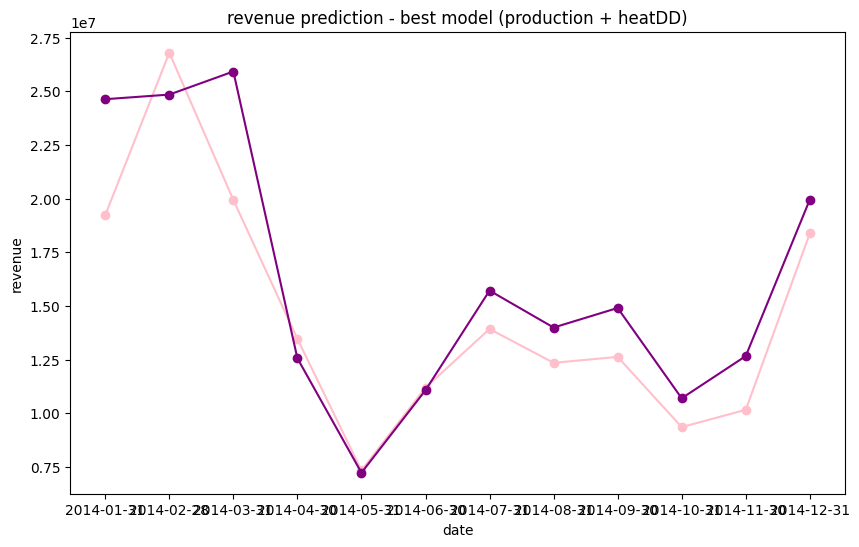

In [40]:
plt.figure(figsize=(10,6))
plt.title('revenue prediction - best model (production + heatDD)')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model5_assessment['date'], model5_assessment['revenue'], marker ='o', color='pink')
plt.plot(model5_assessment['date'], model5_assessment['model5_predicted_revenue'], marker ='o', color='purple')

# The best model is Model 5 - Production + heatDD because it has the lowest MAPE score of 0.1357 while the other models had higher MAPE scores.